In [147]:
import math
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from reproject import reproject_interp
from astropy.convolution import Gaussian2DKernel, convolve

In [149]:
def getDataFromFits(imageName=None):
    # continuum image
    w      = WCS(imageName, naxis=2)

    # read in image
    hdu    = fits.open(imageName)
    header = hdu[0].header
    data1  = hdu[0].data
    hdu.close()
    data   = np.squeeze(data1)
    return data, header, w

In [151]:
StokesIFn = 'HOPS-182.StokesI.fits'
StokesQFn = 'HOPS-182.StokesQ.fits'
StokesUFn = 'HOPS-182.StokesU.fits'
DustContFn = 'HOPS-182_cont.fits'

IMap, IHdr, wcsI = getDataFromFits(StokesIFn)
QMap, QHdr, wcsQ = getDataFromFits(StokesQFn)
UMap, UHdr, wcsU = getDataFromFits(StokesUFn)
DustMap, DustHdr, wcsDust = getDataFromFits(DustContFn)

# Calculate resolutions
res1 = math.sqrt(IHdr['BMAJ'] * IHdr['BMIN']) * 3600  # IMap resolution in arcsec
res2 = math.sqrt(DustHdr['BMAJ'] * DustHdr['BMIN']) * 3600  # DustMap resolution in arcsec

print(f"Resolution of IMap: {res1} arcsec")
print(f"Resolution of DustMap: {res2} arcsec")

print(IMap.shape, DustMap.shape)

#print(IHdr)
#print('###############################')
#print(DustHdr)

Resolution of IMap: 0.7333360508208372 arcsec
Resolution of DustMap: 1.1552065254387407 arcsec
(512, 512) (432, 432)


In [153]:
sigma = math.sqrt(res2**2 - res1**2)  # in arcseconds
pixel_scale = abs(IHdr['CDELT2']) * 3600  # arcseconds per pixel
sigma_pixel = sigma / pixel_scale  # sigma in pixels

print(f"Sigma for Gaussian kernel: {sigma} arcsec")
print(f"Sigma in pixels: {sigma_pixel}")

Sigma for Gaussian kernel: 0.8925919297096218 arcsec
Sigma in pixels: 8.925919297095504


In [155]:
kernel = Gaussian2DKernel(sigma_pixel)
IMap_convolved = convolve(IMap, kernel)
QMap_convolved = convolve(QMap, kernel)
UMap_convolved = convolve(UMap, kernel)
IHdr['BMAJ'] = DustHdr['BMAJ']
IHdr['BMIN'] = DustHdr['BMIN']
IHdr['BPA'] = DustHdr['BPA']
QHdr['BMAJ'] = DustHdr['BMAJ']
QHdr['BMIN'] = DustHdr['BMIN']
QHdr['BPA'] = DustHdr['BPA']
UHdr['BMAJ'] = DustHdr['BMAJ']
UHdr['BMIN'] = DustHdr['BMIN']
UHdr['BPA'] = DustHdr['BPA']

fits.writeto('IMap_convolved.fits', IMap_convolved, IHdr, overwrite=True)
fits.writeto('QMap_convolved.fits', QMap_convolved, QHdr, overwrite=True)
fits.writeto('UMap_convolved.fits', UMap_convolved, UHdr, overwrite=True)

In [157]:
IconFn = 'IMap_convolved.fits'
QconFn = 'QMap_convolved.fits'
UconFn = 'UMap_convolved.fits'

IconMap, IconHdr, wcsIcon = getDataFromFits(IconFn)
QconMap, QconHdr, wcsQcon = getDataFromFits(QconFn)
UconMap, UconHdr, wcsUcon = getDataFromFits(UconFn)


IMap_reprojected, Ifootprint = reproject_interp(
    (IconMap, wcsIcon),  # Input map and its WCS
    wcsDust,           # Target WCS (from Map B)
    shape_out=DustMap.shape,  # Shape of the output map (same as Map B)
)

QMap_reprojected, Qfootprint = reproject_interp(
    (QconMap, wcsQcon),  # Input map and its WCS
    wcsDust,           # Target WCS (from Map B)
    shape_out=DustMap.shape,  # Shape of the output map (same as Map B)
)

UMap_reprojected, Ufootprint = reproject_interp(
    (UconMap, wcsUcon),  # Input map and its WCS
    wcsDust,           # Target WCS (from Map B)
    shape_out=DustMap.shape,  # Shape of the output map (same as Map B)
)

fits.writeto('IMap_convilved_reprojected.fits', IMap_reprojected, DustHdr, overwrite=True)
fits.writeto('QMap_convilved_reprojected.fits', QMap_reprojected, DustHdr, overwrite=True)
fits.writeto('UMap_convilved_reprojected.fits', UMap_reprojected, DustHdr, overwrite=True)

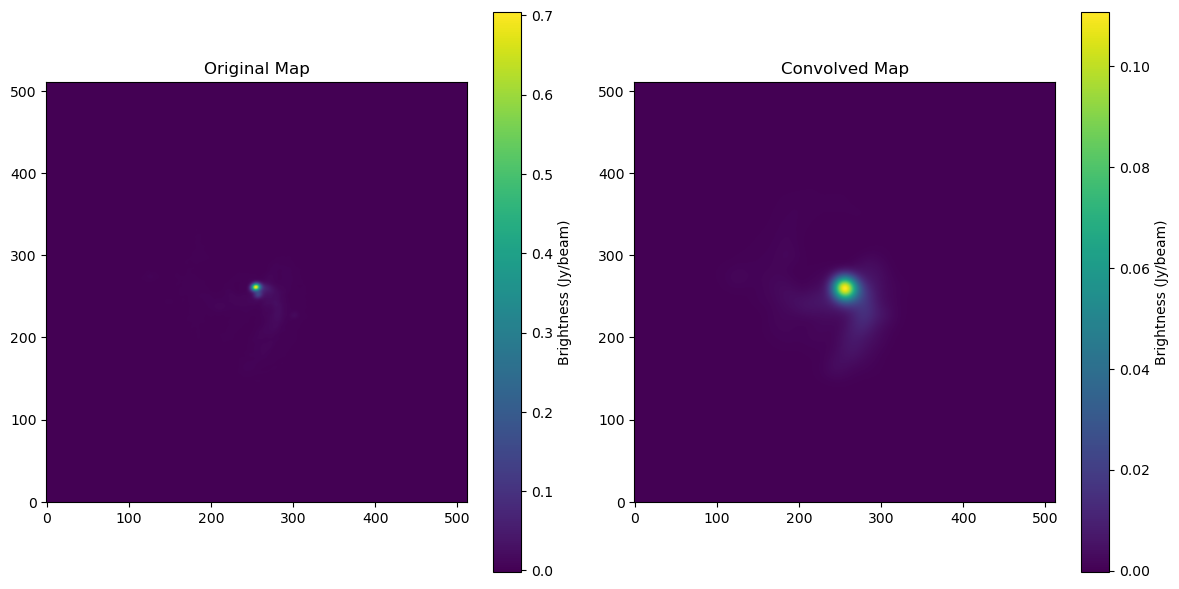